## Unit conversion

In [18]:
# convert to unit byte (kilobyte, megabyte, gigabyte)
byte_units = {
    "Bytes"   : 1, 
    "KBytes"  : 1024,
    "MBytes"  : 1024*1024,
    "GBytes"  : 1024*1024*1024,
}

# convert to unit bits/sec (kilobits, megabits, gigabits)
bit_units = {
    "bits/sec"  : 1,
    "Kbits/sec" : 1e3,
    "Mbits/sec" : 1e6,
    "Gbits/sec" : 1e9,
}
# for the Transfer col
def to_bytes (val, unit):
    return val * byte_units[unit]
# for the Bitrate col
def to_mbits (val, unit):
    return val * bit_units[unit] / 1e6

## Regex processors

In [19]:
import re 

# Server listening on 5201 (test #n)
TEST_HEADER_RE = re.compile(r"Server listening on \d+ \(test #(\d+)\)")

# [  6]   0.00-1.00   sec  4.25 MBytes  35.6 Mbits/sec    8   35.4 KBytes
# [SUM]   0.00-1.00   sec  17.0 MBytes   142 Mbits/sec   51
INTERVAL_RE = re.compile(
    r"^\[\s*(?P<id>\d+|SUM)\]\s+"
    r"(?P<start>\d+\.\d+)-(?P<end>\d+\.\d+)\s+sec\s+"
    r"(?P<xfer_val>[\d.]+)\s+(?P<xfer_unit>[KMG]?Bytes)\s+"
    r"(?P<rate_val>[\d.]+)\s+(?P<rate_unit>[KMG]?bits/sec)"
    r"(?:\s+(?P<retr>\d+))?"
    r"(?:\s+(?P<cwnd_val>[\d.]+)\s+(?P<cwnd_unit>[KMG]?Bytes))?"
)

# [  6]   0.00-30.01  sec  63.8 MBytes  17.8 Mbits/sec  243            sender
# [SUM]   0.00-30.01  sec   323 MBytes  90.4 Mbits/sec  1175           sender
FINAL_RE = re.compile(
    r"^\[\s*(?P<id>\d+|SUM)\]\s+"
    r"(?P<start>\d+\.\d+)-(?P<end>\d+\.\d+)\s+sec\s+"
    r"(?P<xfer_val>[\d.]+)\s+(?P<xfer_unit>[KMG]?Bytes)\s+"
    r"(?P<rate_val>[\d.]+)\s+(?P<rate_unit>[KMG]?bits/sec)"
    r"(?:\s+(?P<retr>\d+))?"
    r"\s+(?P<role>sender|receiver)\s*$"
)

## Single file reader

It reads a log file and write it to a dataframe. 

In [20]:
import pandas as pd

def parse_log(filepath):
    
    intervals = []
    finals = []
    current_test = None

    with open(filepath, "r") as f:
        for line in f: 
            line = line.strip()

            m = TEST_HEADER_RE.match(line)
            if m:
                current_test = int(m.group(1))
                continue
            if current_test is None:
                continue
            
            m = FINAL_RE.match(line)
            if m:
                finals.append({
                    "test_id": current_test,
                    "stream_id": m.group("id"),
                    "start_s": float(m.group("start")),
                    "end_s": float(m.group("end")),
                    "transfer_bytes": to_bytes(float(m.group("xfer_val")), m.group("xfer_unit")),
                    "bitrate_mbps": to_mbits(float(m.group("rate_val")), m.group("rate_unit")),
                    "retr": int(m.group("retr")) if m.group("retr") else None,
                    "cwnd_bytes": None,
                    "kind": "final",
                    "role": m.group("role"),
                })
                continue

            m = INTERVAL_RE.match(line)
            if m:
                cwnd = to_bytes(float(m.group("cwnd_val")), m.group("cwnd_unit")) \
                    if m.group("cwnd_val") else None
                intervals.append({
                    "test_id": current_test,
                    "stream_id": m.group("id"),
                    "start_s": float(m.group("start")),
                    "end_s": float(m.group("end")),
                    "transfer_bytes": to_bytes(float(m.group("xfer_val")), m.group("xfer_unit")),
                    "bitrate_mbps": to_mbits(float(m.group("rate_val")), m.group("rate_unit")),
                    "retr": int(m.group("retr")) if m.group("retr") else None,
                    "cwnd_bytes": cwnd,
                    "kind": "interval",
                    "role": None,
                })

    df_intervals = pd.DataFrame(intervals)
    df_finals = pd.DataFrame(finals)
    
    return df_intervals, df_finals

In [21]:
import json

def parse_json_log(path):

    finals = []
    intervals = []

    with open(path,'r') as f:
        data = f.read()
    decoder = json.JSONDecoder()
    obj, _ = decoder.raw_decode(data)  
    # print(obj)

    start = obj['start']
    end_obj = obj['end']
    intervals_obj = obj['intervals'] 
    end_streams = end_obj['streams']
    end_streams_receiver = end_streams[0]['receiver']  if 'receiver' in end_streams[0] else end_streams[1]['receiver']
    end_recv = end_obj['sum_received']
    end_sent = end_obj['sum_sent']

    finals.append({
                    "test_id": 0,
                    "stream_id": end_streams_receiver['socket'],
                    "start_s": float(end_recv['start']),
                    "end_s": float(end_recv['end']),
                    "transfer_bytes": float(end_recv['bytes']),
                    "bitrate_mbps": to_mbits(float(end_recv['bits_per_second']), 'bits/sec'),
                    "retr": 0,
                    "cwnd_bytes": None,
                    "kind": "final",
                    "role": "receiver",
                })

    for item in intervals_obj:
        streams = item['streams']
        stream = streams[0]
        sum = item['sum']
        
        intervals.append({
            "test_id": 0,
            "stream_id": stream['socket'],
            "start_s": float(sum['start']),
            "end_s": float(sum["end"]),
            "transfer_bytes": float(sum['bytes']),
            "bitrate_mbps": to_mbits(float(sum['bits_per_second']), 'bits/sec'),
            "retr": 0,
            "cwnd_bytes": None,
            "kind": "interval",
            "role": "receiver",
        })

    df_intervals = pd.DataFrame(intervals)
    df_finals = pd.DataFrame(finals)
    
    return df_intervals, df_finals



## Performance stats printer

For each configuration, we print out some basic performance summary in plain text. With each configuration, we repeat the experiment eight times in total (four times in one sitting, then four additional times on another day) to reduce variance cause by any unpredictable environmental effects. We give a summary of the performance over these trials. 

In [22]:
# using df_finals should be sufficient
# it should be a summary of the metrics over the entire 30 seconds
def print_summary(df, filepath):

    print(f"\nPerformance summary for test {filepath}")
    chunk = df[df["stream_id"] == "SUM"]
    print(f"Bytes transferred: max {chunk["transfer_bytes"].max()} | min {chunk["transfer_bytes"].min()} | mean {chunk["transfer_bytes"].mean():.2f}")
    print(f"Bitrate: max {chunk["bitrate_mbps"].max()} | min {chunk["bitrate_mbps"].min()} | mean {chunk["bitrate_mbps"].mean():.2f}")
    print(f"Retransmission: max {chunk["retr"].max()} | min {chunk["retr"].min()} | mean {chunk["retr"].mean():.2f}")

## Visualizing performance per test

For each test, we draw **three** plots stacked together, sharing the same x-axis.

1. A time series plot with the y-axis being bitrate (Mbits/sec). 
2. Second plot is a bar chart with the y-axis being retransmission count.
3. Third plot is a time series plot with the y-axis being congestion window size (Bytes). 

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatch

colors = list(mcolors.XKCD_COLORS)
# print(type(colors))

def draw_plot(df):

    # list of stream ids
    stream_ids = sorted(
        [sid for sid in df["stream_id"].unique() if sid != "SUM"],
        key=int
    )

    # make one figure for each test
    for test_id in sorted(df["test_id"].unique()):
        chunk = df[df["test_id"] == test_id]

        # set axes and dimensions
        fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
        ax_br, ax_retr, ax_cwnd = axes

        # (1) bitrate plot
        for sid in stream_ids:
            curr_stream = chunk[chunk["stream_id"] == sid]
            ax_br.plot(curr_stream["start_s"], curr_stream["bitrate_mbps"], label=f"stream {sid}", color=colors[len(colors)%(int(sid)*8)])

        s_sum = chunk[chunk["stream_id"] == "SUM"]
        ax_br.plot(s_sum["start_s"], s_sum["bitrate_mbps"], color="black", label="SUM")

        ax_br.set_ylabel("Bitrate (Mbps)")
        ax_br.set_title(f"Test #{test_id}")
        ax_br.legend()

        # (2) retransmission count plot 
        for sid in stream_ids:
            curr_stream = chunk[chunk["stream_id"] == sid]
            ax_retr.bar(curr_stream["start_s"], curr_stream["retr"], label=f"stream {sid}", color=colors[len(colors)%(int(sid)*8)], alpha=0.8)

        s_sum = chunk[chunk["stream_id"] == "SUM"]
        ax_retr.plot(s_sum["start_s"], s_sum["retr"], color="black", label="SUM")
        ax_retr.set_ylabel("Retransmits")
        ax_retr.legend()

        # (3) congestion window size plot 
        for sid in stream_ids:
            curr_stream = chunk[chunk["stream_id"] == sid]
            ax_cwnd.plot(curr_stream["start_s"], curr_stream["cwnd_bytes"] / 1024, label=f"stream {sid}", color=colors[len(colors)%(int(sid)*8)])

        ax_cwnd.set_ylabel("Cwnd (KBytes)")
        ax_cwnd.set_xlabel("Time (s)")

        plt.show()

        # plot for just one test for now, comment it out
        break

## Visualizing performance with backscatter ON/OFF

All logfiles ending with `_norf` record WiFi performance when no backscatter communication is present. We use it as a benchmark against which we compare the performance when backscatter is on.

(bitrate, number of retransmission, and congestion window size)

In [24]:
OUT_DIR = "analysis"
LOG_FILES = [
    "../data/20260417/adjacent_norf.log",
    "../data/20260417/short_norf.log",
    "../data/20260417/window_norf.log"
]

for filepath in LOG_FILES:
    df_intervals, df_finals = parse_log(filepath)
    # draw_plot(df_intervals)
    

## Experiment

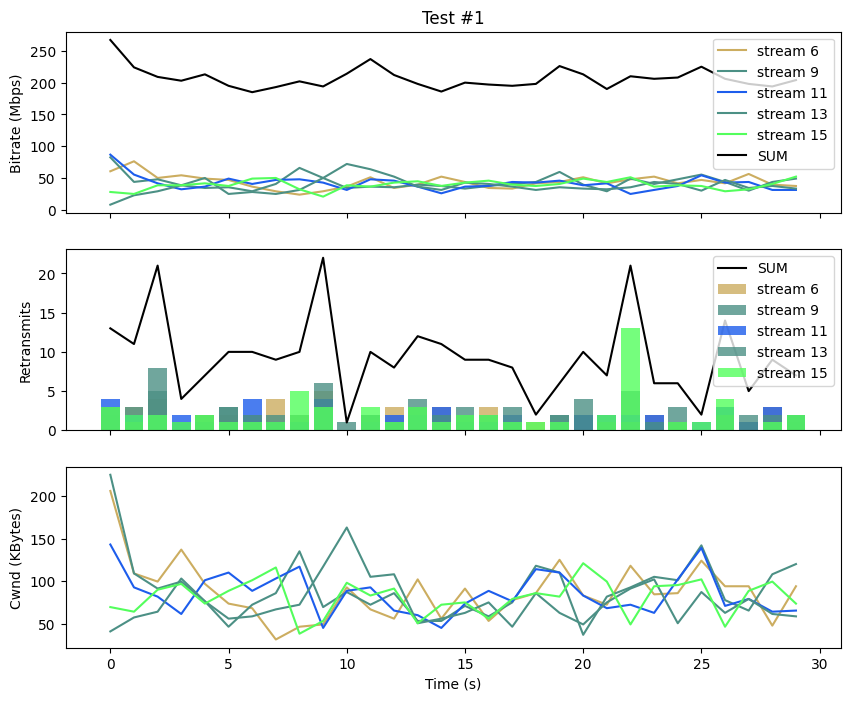


Performance summary for test ../data/20260417/window_norf.log
Bytes transferred: max 775946240.0 | min 673185792.0 | mean 723779584.00
Bitrate: max 207.0 | min 179.0 | mean 193.00
Retransmission: max 372 | min 280 | mean 312.25


In [25]:
OUT_DIR = "analysis"
LOG_FILES = [
    # "../data/20260417/1MHz_25percent.log",
    # "../data/20260417/adjacent_norf.log", 
    "../data/20260417/window_norf.log"
    # "../data/20260430/close_norf.jsonl"
]

for filepath in LOG_FILES:
    if filepath.endswith('.jsonl'):
        df_intervals, df_finals = parse_json_log(filepath)
    else:
        df_intervals, df_finals = parse_log(filepath)
    draw_plot(df_intervals)
    print_summary(df_finals, filepath)